# Этап 2 — Признаки узлов

Для каждого ингредиента (узел графа I) строим вектор из 7 структурных признаков:

| Признак | Смысл |
|---------|-------|
| `degree` / `degree_w` | Число соседей (без веса / с весом) |
| `pagerank` | Глобальная важность в графе |
| `clustering` | Насколько соседи связаны между собой |
| `kcore` | Принадлежность к плотному ядру |
| `betweenness` | Посредничество между узлами |
| `log_freq` | log(число рецептов) |

**Результат:** `node_features_structural.csv` и `node_features.npz` — используются в этапах 3–5.

In [5]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from ingredient_ru import ru

OUT = Path('output_graphs')
SEED = 42

# Загружаем граф и частоты из этапа 1
I = nx.read_graphml(OUT / 'ingredient_graph.graphml')
_freq_df = pd.read_csv(OUT / 'ingredient_freq.csv')
ing_freq = dict(zip(_freq_df['ingredient'], _freq_df['freq']))
nodes = sorted(I.nodes())
print(f'Загружен граф I: {I.number_of_nodes():,} узлов, {I.number_of_edges():,} рёбер')

Загружен граф I: 7,199 узлов, 418,645 рёбер


## 2.1 Вычисление признаков

`betweenness` — приближённый (k=300 случайных источников)

In [6]:
t0 = time.time()

pagerank    = nx.pagerank(I, weight='weight', alpha=0.85)
clustering  = nx.clustering(I, weight='weight')
kcore       = nx.core_number(I)
betweenness = nx.betweenness_centrality(I, k=300, normalized=True, weight='weight', seed=SEED)

feat_df = pd.DataFrame(index=nodes)
feat_df.index.name = 'ingredient'
feat_df['degree']      = [I.degree(n) for n in nodes]
feat_df['degree_w']    = [I.degree(n, weight='weight') for n in nodes]
feat_df['pagerank']    = feat_df.index.map(pagerank)
feat_df['clustering']  = feat_df.index.map(clustering)
feat_df['kcore']       = feat_df.index.map(kcore)
feat_df['betweenness'] = feat_df.index.map(betweenness)
feat_df['log_freq']    = feat_df.index.map(lambda n: np.log1p(ing_freq.get(n, 0)))

print(f'Готово за {time.time()-t0:.0f}с. Форма: {feat_df.shape}')
display(feat_df.describe().round(4))

Готово за 424с. Форма: (7199, 7)


,degree,degree_w,pagerank,clustering,kcore,betweenness,log_freq
count,7199.0000,7.199000e+03,7199.0000,7199.0000,7199.0000,7199.0000,7199.0000
mean,116.3064,1.996281e+04,0.0001,0.0005,63.6854,0.0002,5.5468
std,336.4176,1.751645e+05,0.0011,0.0002,78.8194,0.0014,1.5332
min,0.0000,0.000000e+00,0.0000,0.0000,0.0000,0.0000,3.9318
25%,12.0000,2.380000e+02,0.0000,0.0004,12.0000,0.0000,4.3944
50%,27.0000,6.640000e+02,0.0000,0.0005,27.0000,0.0000,5.0814
75%,80.0000,2.946000e+03,0.0000,0.0007,79.0000,0.0001,6.2236
max,6743.0000,8.238311e+06,0.0541,0.0020,276.0000,0.0523,13.7740


## 2.2 Визуализация: PCA + топ ингредиентов

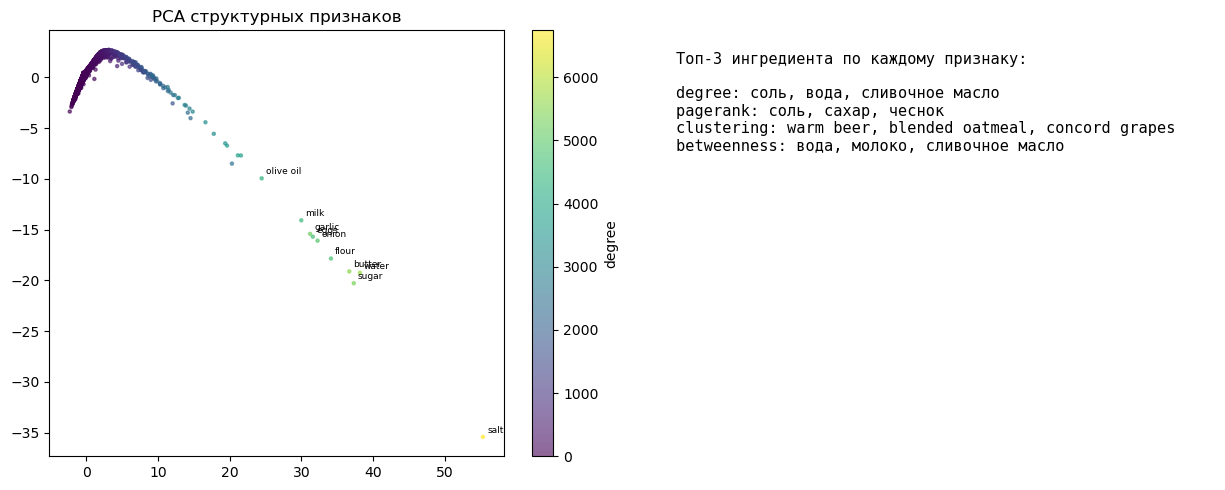

In [9]:
COLS = ['degree', 'degree_w', 'pagerank', 'clustering', 'kcore', 'betweenness', 'log_freq']
X = StandardScaler().fit_transform(feat_df[COLS].values)

pca = PCA(n_components=2, random_state=SEED)
xy  = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc = axes[0].scatter(xy[:, 0], xy[:, 1], c=feat_df['degree'], cmap='viridis', s=5, alpha=0.6)
plt.colorbar(sc, ax=axes[0], label='degree')
axes[0].set_title(f'PCA структурных признаков')
# подписываем топ-10 по degree (dict-lookup O(1) вместо list.index)
node_idx = {n: i for i, n in enumerate(nodes)}
for n in feat_df['degree'].nlargest(10).index:
    if n in node_idx:
        axes[0].annotate(n, xy[node_idx[n]], fontsize=6.5, xytext=(3, 3), textcoords='offset points')

# Топ-8 по каждому признаку — таблица
axes[1].axis('off')
lines = []
for col in ['degree', 'pagerank', 'clustering', 'betweenness']:
    top3 = [ru(n) for n in feat_df[col].nlargest(3).index]
    lines.append(f"{col}: {', '.join(top3)}")
axes[1].text(0.05, 0.95, 'Топ-3 ингредиента по каждому признаку:\n\n' + '\n'.join(lines),
             va='top', fontsize=11, transform=axes[1].transAxes, family='monospace')

plt.tight_layout()
plt.savefig(OUT / 'pca_structural.png', dpi=120)
plt.show()

## 2.3 Сохранение

In [8]:
COLS = ['degree', 'degree_w', 'pagerank', 'clustering', 'kcore', 'betweenness', 'log_freq']
X_struct = StandardScaler().fit_transform(feat_df[COLS].values).astype(np.float32)

feat_df.to_csv(OUT / 'node_features_structural.csv')

np.savez_compressed(
    OUT / 'node_features.npz',
    nodes     = np.array(nodes, dtype=object),
    X_struct  = X_struct,
    feat_cols = np.array(COLS, dtype=object),
)

print('Сохранено: node_features_structural.csv, node_features.npz')
print(f'Матрица признаков: {X_struct.shape}')

Сохранено: node_features_structural.csv, node_features.npz
Матрица признаков: (7199, 7)
